# ESN Exploration: MSFT Single-Stock Forecasting

This notebook explores Echo State Networks on Microsoft (`MSFT`) daily market data. It has two parts:

- A reproducible DeepESN regression experiment on MSFT next-step log returns.
- A W&B Bayesian sweep configuration for 50 single-layer ESN runs with reasonable reservoir and readout hyperparameters.

The target is the next normalized MSFT log return generated by `make_single_stock_df`.

In [23]:
from pathlib import Path
import random
import sys
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import wandb
from sklearn.metrics import precision_score
from src.my_engine.utils import get_direction_accuracy

from src.my_engine.sweep import terminate_sweep, get_best_sweep_run_and_config
from src.my_engine.config import MetricsConfig, ModelConfig, TrainerConfig
from src.my_engine.data import get_dataloaders
from src.my_engine.financial_data import make_single_stock_df
from src.my_engine.sweep import make_train_sweep
from src.my_engine.trainer import Trainer, RidgeRegressionTrainer
from src.my_engine.utils import build_model, make_optimizer
from pprint import pprint

In [3]:
PROJECT_ROOT = '/home/alexsearle/Documents/Bucknell/SP26/csci357_final_project'
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

if os.getcwd() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

In [4]:
SEED = 357
TICKER = "MSFT"
PERIOD = "5y"
WINDOW_SIZE = 30
TRAIN_SPLIT = 0.75
VAL_SPLIT = 0.15

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## MSFT Data

`make_single_stock_df` downloads MSFT data from Yahoo Finance, engineers price/volume/volatility features, standardizes the features using the training segment, and converts the result into rolling windows. The model sees a 30-day sequence and predicts the next scaled log return.

In [8]:
train_ds_raw, val_ds_raw, test_ds_raw, feature_scaler, features = make_single_stock_df(
    ticker=TICKER,
    period=PERIOD,
    train_split=TRAIN_SPLIT,
    val_split=VAL_SPLIT,
    window_size=WINDOW_SIZE,
)

def with_column_targets(dataset: TensorDataset) -> TensorDataset:
    X, y = dataset.tensors
    if y.ndim == 1:
        y = y.unsqueeze(1)
    return TensorDataset(X.float(), y.float())

train_ds = with_column_targets(train_ds_raw)
val_ds = with_column_targets(val_ds_raw)
test_ds = with_column_targets(test_ds_raw) if test_ds_raw is not None else None

# make_single_stock_df returns validation windows from the full post-train span.
# Trim it so validation and test are disjoint for model selection vs. final evaluation.
if test_ds is not None:
    intended_val_windows = len(val_ds) - len(test_ds) - WINDOW_SIZE - 1
    if intended_val_windows <= 0:
        raise ValueError("Validation split is too small for the selected window size.")
    val_X, val_y = val_ds.tensors
    val_ds = TensorDataset(val_X[:intended_val_windows], val_y[:intended_val_windows])

n_features = train_ds.tensors[0].shape[-1]
print(f"train windows: {len(train_ds):,}")
print(f"val windows:   {len(val_ds):,}")
print(f"test windows:  {len(test_ds):,}")
print(f"sequence shape: {tuple(train_ds.tensors[0].shape[1:])}")
print(f"features ({len(features)}): {features}")

[*********************100%***********************]  1 of 1 completed


train windows: 873
val windows:   149
test windows:  91
sequence shape: (30, 11)
features (11): ['log_returns', 'log_volume', 'log_intraday_chng', '10_log_returns_ma', '20_log_returns_ma', '50_log_returns_ma', 'open_close', 'overnight_gap', 'ret_1', 'ret_5', 'variance']


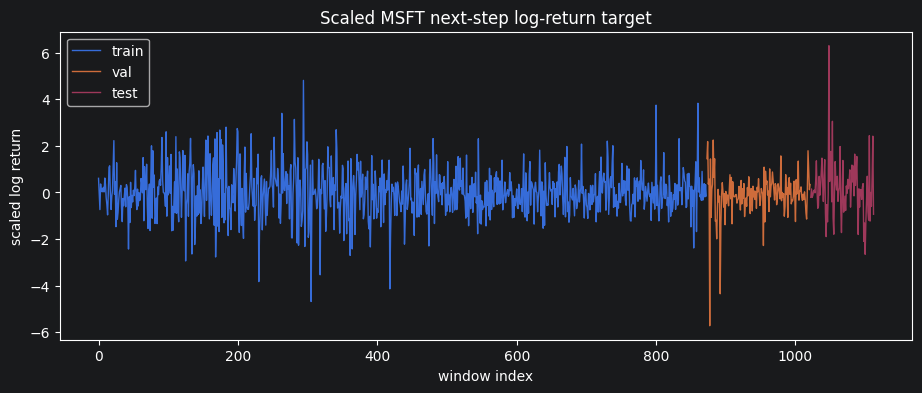

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_ds.tensors[1].numpy(), label="train", linewidth=1.0)
ax.plot(
    range(len(train_ds), len(train_ds) + len(val_ds)),
    val_ds.tensors[1].numpy(),
    label="val",
    linewidth=1.0,
)
if test_ds is not None:
    offset = len(train_ds) + len(val_ds)
    ax.plot(
        range(offset, offset + len(test_ds)),
        test_ds.tensors[1].numpy(),
        label="test",
        linewidth=1.0,
    )
ax.set_title("Scaled MSFT next-step log-return target")
ax.set_xlabel("window index")
ax.set_ylabel("scaled log return")
ax.legend()
plt.show()

## Training Helpers

The project trainer supports regression metrics through `MetricsConfig`. The helper below evaluates predictions in scaled target space and in approximate original log-return units by inverting the scaler column corresponding to `log_returns`.

In [10]:
def inverse_scaled_target(values):
    target_idx = features.index("log_returns")
    values = np.asarray(values).reshape(-1)
    return values * feature_scaler.scale_[target_idx] + feature_scaler.mean_[target_idx]

@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds = []
    targets = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        preds.append(model(X_batch).cpu())
        targets.append(y_batch.cpu())
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

def regression_report(pred_scaled, y_scaled):
    pred_scaled = np.asarray(pred_scaled).reshape(-1)
    y_scaled = np.asarray(y_scaled).reshape(-1)
    pred_raw = inverse_scaled_target(pred_scaled)
    y_raw = inverse_scaled_target(y_scaled)
    return {
        "scaled_mse": float(np.mean((pred_scaled - y_scaled) ** 2)),
        "scaled_mae": float(np.mean(np.abs(pred_scaled - y_scaled))),
        "raw_log_return_mse": float(np.mean((pred_raw - y_raw) ** 2)),
        "raw_log_return_mae": float(np.mean(np.abs(pred_raw - y_raw))),
        "directional_accuracy": float(np.mean(np.sign(pred_raw) == np.sign(y_raw))),
    }

def evaluate_model(model, loader, device):
    pred_scaled, y_scaled = predict(model, loader, device)
    return regression_report(pred_scaled, y_scaled), pred_scaled, y_scaled

## Baselines

Use simple baselines before judging the ESN. For stock returns, a zero-return forecast is often difficult to beat on MSE, so it is a useful sanity check.

In [11]:
zero_val = np.zeros_like(val_ds.tensors[1].numpy())
last_step_return_val = val_ds.tensors[0][:, -1, features.index("log_returns")].unsqueeze(1).numpy()

baseline_results = pd.DataFrame(
    [
        {"model": "zero_scaled_return", **regression_report(zero_val, val_ds.tensors[1].numpy())},
        {"model": "last_observed_return", **regression_report(last_step_return_val, val_ds.tensors[1].numpy())},
    ]
)
baseline_results

,model,scaled_mse,scaled_mae,raw_log_return_mse,raw_log_return_mae,directional_accuracy
0,zero_scaled_return,0.829277,0.564121,0.000234,0.009477,0.563758
1,last_observed_return,1.686957,0.850851,0.000476,0.014294,0.489933


## DeepESN Experiment

This model stacks fixed reservoirs and trains only the readout. The reservoir size and depth are deliberately moderate so the cell remains notebook-friendly while still testing whether deeper reservoir dynamics help on MSFT.

In [13]:
deep_esn_config = ModelConfig(
    model_type="deep_esn",
    reservoir_size=300,
    rnn_num_layers=3,
    spectral_radius=0.95,
    reservoir_sparsity=0.85,
    input_scale=0.25,
    leak_rate=0.35,
    hidden_units=[128, 64],
    dropout=[0.10, 0.10],
)

trainer_config = TrainerConfig(
    trainer_batch_size=128,
    evaluator_batch_size=512,
    learning_rate=1e-3,
    num_epochs=40,
    optimizer_name="Adam",
    weight_decay=1e-4,
    early_stopping_patience=8,
    early_stopping_min_delta=1e-5,
    use_scheduler=True,
    scheduler_type="reduce_on_plateau",
    scheduler_patience=3,
    scheduler_gamma=0.5,
    scheduler_min_lr=1e-5,
    device=device,
    num_workers=0,
    pin_memory=False,
)

train_loader, val_loader, test_loader = get_dataloaders(
    train_ds,
    val_ds,
    test_ds,
    train_batch_size=trainer_config.trainer_batch_size,
    eval_batch_size=trainer_config.evaluator_batch_size,
    time_series=True,
)

metrics_config = MetricsConfig(task="regression", names=["mae", "mse", "r2"])

deep_esn_model = build_model(
    input_spec=n_features,
    num_outputs=1,
    config=deep_esn_config,
)
optimizer = make_optimizer(deep_esn_model.parameters(), trainer_config)
criterion = nn.MSELoss()

print(deep_esn_model)
print("parameters:", deep_esn_model.num_parameters())

DeepESN(input=11, layers=3, reservoir=300, out=1)
parameters: (453601, 0)


In [14]:
trainer = RidgeRegressionTrainer(
    model=deep_esn_model,
    criterion=criterion,
    config=trainer_config,
)

history = trainer.fit(train_loader, val_loader)
history

{'train_loss': 0.5291722250967911,
 'train_acc': 0.0,
 'val_loss': 3.678473472595215,
 'val_acc': 0.0}

In [15]:
val_report, val_pred_scaled, val_y_scaled = evaluate_model(deep_esn_model, val_loader, device)
test_report = None
if test_loader is not None:
    test_report, test_pred_scaled, test_y_scaled = evaluate_model(deep_esn_model, test_loader, device)

pd.DataFrame(
    [
        {"split": "validation", **val_report},
        *([] if test_report is None else [{"split": "test", **test_report}]),
    ]
)

,split,scaled_mse,scaled_mae,raw_log_return_mse,raw_log_return_mae,directional_accuracy
0,validation,3.678473,1.527621,0.001038,0.025663,0.483221
1,test,5.829275,1.880628,0.001645,0.031594,0.593407


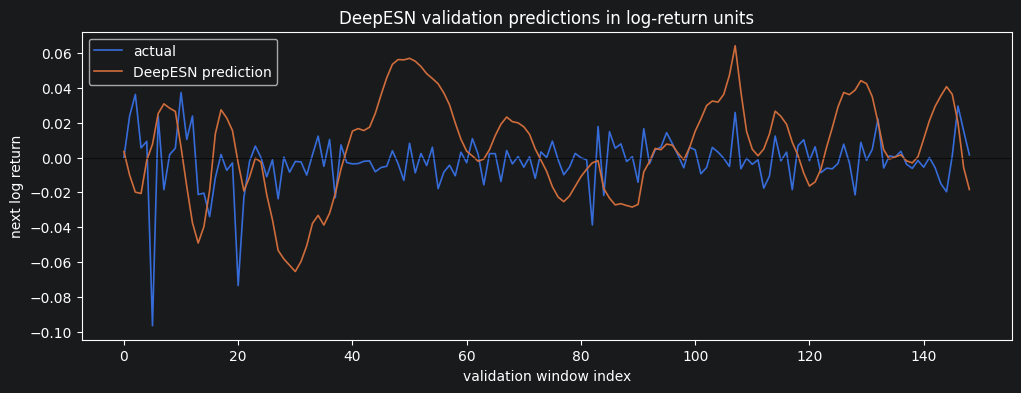

In [11]:
val_pred_raw = inverse_scaled_target(val_pred_scaled)
val_y_raw = inverse_scaled_target(val_y_scaled)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(val_y_raw, label="actual", linewidth=1.2)
ax.plot(val_pred_raw, label="DeepESN prediction", linewidth=1.2)
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("DeepESN validation predictions in log-return units")
ax.set_xlabel("validation window index")
ax.set_ylabel("next log return")
ax.legend()
plt.show()

KeyError: 'train_losses'

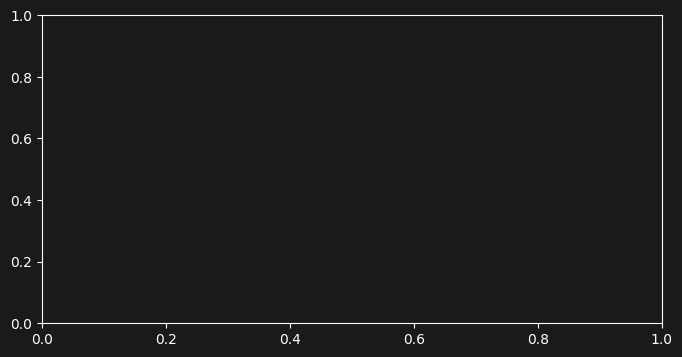

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["train_losses"], label="train")
ax.plot(history["val_losses"], label="validation")
ax.set_title("DeepESN MSE loss")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.legend()
plt.show()

## Bayesian Sweep: 50 ESNs

The sweep below searches single-layer ESNs. It minimizes validation loss over reservoir dynamics, readout size, learning rate, and regularization. Set `RUN_SWEEP = True` after logging into W&B.

In [42]:

WANDB_PROJECT = "csci357-msft-esn"
WANDB_ENTITY = None

esn_sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_loss", "goal": "minimize"},
    "early_terminate": {"type": "hyperband", "min_iter": 8},
    "parameters": {
        "model_type": {"value": "esn"},
        "num_epochs": {"value": 35},
        "loss_name": {"value": "mse"},
        "reservoir_size": {"values": [100, 200, 300, 500]},
        "spectral_radius": {"distribution": "uniform", "min": 0.4, "max": 1.3},
        "reservoir_sparsity": {"distribution": "uniform", "min": 0.50, "max": 0.95},
        "input_scale": {"distribution": "uniform", "min": 0.05, "max": 0.80},
        "leak_rate": {"distribution": "uniform", "min": 0.05, "max": 1.00},
        "ridge_alpha": {"distribution": "log_uniform_values", "min": 1e-5, "max": 6},
        "hidden_units": {"values": [[32], [64], [128], [128, 64], [256, 128]]},
        "num_workers": {"value": 0},
        "pin_memory": {"value": False},
    },
}

esn_sweep_config

{'method': 'bayes',
 'metric': {'name': 'val_loss', 'goal': 'minimize'},
 'early_terminate': {'type': 'hyperband', 'min_iter': 8},
 'parameters': {'model_type': {'value': 'esn'},
  'num_epochs': {'value': 35},
  'loss_name': {'value': 'mse'},
  'reservoir_size': {'values': [100, 200, 300, 500]},
  'spectral_radius': {'distribution': 'uniform', 'min': 0.4, 'max': 1.3},
  'reservoir_sparsity': {'distribution': 'uniform', 'min': 0.5, 'max': 0.95},
  'input_scale': {'distribution': 'uniform', 'min': 0.05, 'max': 0.8},
  'leak_rate': {'distribution': 'uniform', 'min': 0.05, 'max': 1.0},
  'ridge_alpha': {'distribution': 'log_uniform_values',
   'min': 1e-05,
   'max': 6},
  'hidden_units': {'values': [[32], [64], [128], [128, 64], [256, 128]]},
  'num_workers': {'value': 0},
  'pin_memory': {'value': False}}}

In [43]:
RUN_SWEEP = True

if RUN_SWEEP:
    sweep_id = wandb.sweep(
        sweep=esn_sweep_config,
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
    )

    train_sweep = make_train_sweep(
        wandb_project_name=WANDB_PROJECT,
        wandb_entity_name=WANDB_ENTITY,
        datasets=(train_ds, val_ds),
        device=device,
        input_spec=n_features,
        num_outputs=1,
        wandb_name_prefix=f"{TICKER.lower()}_single_esn",
        trainer_type="ridge"
    )

    wandb.agent(sweep_id, function=train_sweep, count=200)
else:
    print("Sweep is configured but not launched. Set RUN_SWEEP = True to start 50 Bayesian ESN runs.")

Create sweep with ID: 0snvev3s
Sweep URL: https://wandb.ai/sas073-bucknell-university/csci357-msft-esn/sweeps/0snvev3s


wandb: Agent Starting Run: w6ttao22 with config:
wandb: 	hidden_units: [32]
wandb: 	input_scale: 0.3377649193259112
wandb: 	leak_rate: 0.6209712095732977
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.6297924934011774
wandb: 	ridge_alpha: 0.0001797613740462131
wandb: 	spectral_radius: 0.8159454538537718
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [32], 'input_scale': 0.3377649193259112, 'leak_rate': 0.6209712095732977, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.6297924934011774, 'ridge_alpha': 0.0001797613740462131, 'spectral_radius': 0.8159454538537718}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.82_sp0.63_wd0.00000
esn
✓ Run complete! Final val_loss: 1.1281, val_acc: 0.00%


wandb: Agent Starting Run: arfdomy8 with config:
wandb: 	hidden_units: [128, 64]
wandb: 	input_scale: 0.36039253176637825
wandb: 	leak_rate: 0.22351089473441493
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 300
wandb: 	reservoir_sparsity: 0.591590336836708
wandb: 	ridge_alpha: 3.840207924084566
wandb: 	spectral_radius: 1.2321338890042803
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [128, 64], 'input_scale': 0.36039253176637825, 'leak_rate': 0.22351089473441493, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 300, 'reservoir_sparsity': 0.591590336836708, 'ridge_alpha': 3.840207924084566, 'spectral_radius': 1.2321338890042803}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs300_sr1.23_sp0.59_wd0.00000
esn
✓ Run complete! Final val_loss: 1.3226, val_acc: 0.00%


...

wandb.config: {'hidden_units': [32], 'input_scale': 0.130903419607786, 'leak_rate': 0.7154286255049336, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.5020064525365534, 'ridge_alpha': 0.013343924573750766, 'spectral_radius': 1.069373476450481}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr1.07_sp0.50_wd0.00000
esn
✓ Run complete! Final val_loss: 0.9773, val_acc: 0.00%


wandb: Agent Starting Run: 82q1djsn with config:
wandb: 	hidden_units: [64]
wandb: 	input_scale: 0.5952677422444316
wandb: 	leak_rate: 0.982000133598362
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.5819247292034988
wandb: 	ridge_alpha: 0.030504774300519823
wandb: 	spectral_radius: 0.6735652670348782
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [64], 'input_scale': 0.5952677422444316, 'leak_rate': 0.982000133598362, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.5819247292034988, 'ridge_alpha': 0.030504774300519823, 'spectral_radius': 0.6735652670348782}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.67_sp0.58_wd0.00000
esn
✓ Run complete! Final val_loss: 0.9269, val_acc: 0.00%


wandb: Agent Starting Run: wdi4n6r1 with config:
wandb: 	hidden_units: [128]
wandb: 	input_scale: 0.38065470521920747
wandb: 	leak_rate: 0.5272896674826298
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.7863906183259983
wandb: 	ridge_alpha: 2.081735904179725e-05
wandb: 	spectral_radius: 1.2033159207536577
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [128], 'input_scale': 0.38065470521920747, 'leak_rate': 0.5272896674826298, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.7863906183259983, 'ridge_alpha': 2.081735904179725e-05, 'spectral_radius': 1.2033159207536577}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr1.20_sp0.79_wd0.00000
esn
✓ Run complete! Final val_loss: 1.0149, val_acc: 0.00%


In [44]:

terminate_sweep(sweep_id)

Sweep 0snvev3s current state is: RUNNING
Stopping sweep sas073-bucknell-university/csci357-msft-esn/0snvev3s


Error processing line 1 of /home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
wandb: Stopping sweep sas073-bucknell-university/csci357-msft-esn/0snvev3s


Sweep sas073-bucknell-university/csci357-msft-esn/0snvev3s stopped successfully


wandb: Done.


True

In [88]:

best_run, best_config, best_metric = get_best_sweep_run_and_config(
    entity="",
    project=WANDB_PROJECT,
    sweep_id=sweep_id,
    metric_name="val_loss",
    maximize=False,
)

print(best_run.name)
print(best_metric)
pprint(best_config)

msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.65_sp0.92_wd0.00000
0.9432549476623536
{'hidden_units': [256, 128],
 'input_scale': 0.7572306493321186,
 'leak_rate': 0.49439784989601854,
 'loss_name': 'mse',
 'model_type': 'esn',
 'num_epochs': 35,
 'num_workers': 0,
 'pin_memory': False,
 'reservoir_size': 100,
 'reservoir_sparsity': 0.9210893884296616,
 'ridge_alpha': 0.0009567832399705826,
 'spectral_radius': 0.6464488192252836}


In [82]:
best_esn_config = ModelConfig(
    model_type=best_config['model_type'],
    leak_rate=best_config['leak_rate'],
    spectral_radius=best_config['spectral_radius'],
    reservoir_size=best_config['reservoir_size'],
    reservoir_sparsity=best_config['reservoir_sparsity'],
    hidden_units=best_config['hidden_units'],
    input_scale=best_config['input_scale'],
)

best_esn_model = build_model(input_spec=len(features), config=best_esn_config, num_outputs=1)

best_esn_trainer_config = TrainerConfig(
    num_epochs=50,
    device=device,
)

train_loader, val_loader, test_loader = get_dataloaders(
    train_ds=train_ds,
    eval_ds=val_ds,
    test_ds=test_ds,
    train_batch_size=best_esn_trainer_config.trainer_batch_size,
    eval_batch_size=best_esn_trainer_config.evaluator_batch_size,
    time_series=True,
)

trainer = RidgeRegressionTrainer(
    model=best_esn_model,
    criterion=torch.nn.MSELoss(),
    config=best_esn_trainer_config,
    ridge_alpha=best_config['ridge_alpha'],
)
best_results = trainer.fit(train_loader, test_loader)

In [84]:
deep_best_dir_acc, true_dirs, pred_dirs = get_direction_accuracy(best_esn_model, test_loader, feature_scaler, features.index('log_returns'))
precision = precision_score(true_dirs, pred_dirs)
print(f"Directional accuracy: {deep_best_dir_acc:.2%}")
print(f"Directional precision: {precision:.2%}")

Directional accuracy: 39.56%
Directional precision: 40.62%


In [89]:
torch.save(best_config, "best_model_archs/esn_msft.pt")

# Testing Different Tickers

In [29]:
train_nvda_ds, val_nvda_ds, test_nvda_ds, nvda_scaler, features = make_single_stock_df("NVDA", "5y")

[*********************100%***********************]  1 of 1 completed


In [18]:
WANDB_PROJECT = "csci357-nvda-esn"
WANDB_ENTITY = None

esn_sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_loss", "goal": "minimize"},
    "early_terminate": {"type": "hyperband", "min_iter": 8},
    "parameters": {
        "model_type": {"value": "esn"},
        "num_epochs": {"value": 35},
        "loss_name": {"value": "mse"},
        "reservoir_size": {"values": [100, 200, 300, 500]},
        "spectral_radius": {"distribution": "uniform", "min": 0.4, "max": 1.3},
        "reservoir_sparsity": {"distribution": "uniform", "min": 0.50, "max": 0.95},
        "input_scale": {"distribution": "uniform", "min": 0.05, "max": 0.80},
        "leak_rate": {"distribution": "uniform", "min": 0.05, "max": 1.00},
        "ridge_alpha": {"distribution": "log_uniform_values", "min": 1e-5, "max": 6},
        "hidden_units": {"values": [[32], [64], [128], [128, 64], [256, 128]]},
        "num_workers": {"value": 0},
        "pin_memory": {"value": False},
    },
}

esn_sweep_config

{'method': 'bayes',
 'metric': {'name': 'val_loss', 'goal': 'minimize'},
 'early_terminate': {'type': 'hyperband', 'min_iter': 8},
 'parameters': {'model_type': {'value': 'esn'},
  'num_epochs': {'value': 35},
  'loss_name': {'value': 'mse'},
  'reservoir_size': {'values': [100, 200, 300, 500]},
  'spectral_radius': {'distribution': 'uniform', 'min': 0.4, 'max': 1.3},
  'reservoir_sparsity': {'distribution': 'uniform', 'min': 0.5, 'max': 0.95},
  'input_scale': {'distribution': 'uniform', 'min': 0.05, 'max': 0.8},
  'leak_rate': {'distribution': 'uniform', 'min': 0.05, 'max': 1.0},
  'ridge_alpha': {'distribution': 'log_uniform_values',
   'min': 1e-05,
   'max': 6},
  'hidden_units': {'values': [[32], [64], [128], [128, 64], [256, 128]]},
  'num_workers': {'value': 0},
  'pin_memory': {'value': False}}}

In [25]:
RUN_SWEEP = True

if RUN_SWEEP:
    sweep_id = wandb.sweep(
        sweep=esn_sweep_config,
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
    )

    train_sweep = make_train_sweep(
        wandb_project_name=WANDB_PROJECT,
        wandb_entity_name=WANDB_ENTITY,
        datasets=(train_nvda_ds, val_nvda_ds),
        device=device,
        input_spec=n_features,
        num_outputs=1,
        wandb_name_prefix=f"{TICKER.lower()}_single_esn",
        trainer_type="ridge"
    )

    wandb.agent(sweep_id, function=train_sweep, count=200)
else:
    print("Sweep is configured but not launched. Set RUN_SWEEP = True to start 50 Bayesian ESN runs.")

Traceback (most recent call last):
  File "/home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/wandb/agents/pyagent.py", line 296, in _run_job
    self._function()
  File "/home/alexsearle/Documents/Bucknell/SP26/csci357_final_project/src/my_engine/sweep.py", line 355, in train_sweep
    print(f"✓ Run complete! Final val_loss: {results['val_loss']:.4f}, val_acc: {results['val_acc'] * 100:.2f}%")
  File "/home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3053, in write
    result = original_write(data, *args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/ipykernel/iostream.py", line 689, in write
    self._schedule_flush()
  File "/home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/ipykernel/iostream.py", line 585, in _schedule_flush
    self.pub_thread.schedule(_schedule_in_thread)
  File "/home/alexsearl

✓ Run complete! Final val_loss: 0.9694, val_acc: 0.00%Create sweep with ID: ylp4x0cq
Sweep URL: https://wandb.ai/sas073-bucknell-university/csci357-nvda-esn/sweeps/ylp4x0cq


Traceback (most recent call last):
  File "/home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/wandb/sdk/wandb_init.py", line 1008, in init
    result = wait_with_progress(
             ^^^^^^^^^^^^^^^^^^^
  File "/home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/wandb/sdk/mailbox/wait_with_progress.py", line 23, in wait_with_progress
    return wait_all_with_progress(
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/wandb/sdk/mailbox/wait_with_progress.py", line 77, in wait_all_with_progress
    return asyncer.run(progress_loop_with_timeout)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/wandb/sdk/lib/asyncio_manager.py", line 136, in run
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/home/alexsearle/anaconda3/envs/csci357/lib/python3.11/concurrent/futures/_base.py", line 456, in result
    r

wandb.config: {'hidden_units': [256, 128], 'input_scale': 0.7835861048395347, 'leak_rate': 0.9359145823368236, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 500, 'reservoir_sparsity': 0.7401171916735563, 'ridge_alpha': 0.00113030440738093, 'spectral_radius': 0.9122268008944784}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs500_sr0.91_sp0.74_wd0.00000
esn
✓ Run complete! Final val_loss: 1.3138, val_acc: 0.00%


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 2lm7g0wu with config:
wandb: 	hidden_units: [256, 128]
wandb: 	input_scale: 0.6118148454242925
wandb: 	leak_rate: 0.09700634295222424
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 300
wandb: 	reservoir_sparsity: 0.6849276773412006
wandb: 	ridge_alpha: 3.338380412477493e-05
wandb: 	spectral_radius: 0.4033885237525286
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


...

wandb.config: {'hidden_units': [128, 64], 'input_scale': 0.06848773368368187, 'leak_rate': 0.0769787148943751, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.8459126989727702, 'ridge_alpha': 1.4849389798903967, 'spectral_radius': 0.697942400124604}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.70_sp0.85_wd0.00000
esn
✓ Run complete! Final val_loss: 0.3759, val_acc: 0.00%


wandb: Agent Starting Run: bzi2ygk4 with config:
wandb: 	hidden_units: [256, 128]
wandb: 	input_scale: 0.2067479340793117
wandb: 	leak_rate: 0.5059268881752428
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.7859919472410373
wandb: 	ridge_alpha: 0.7686407791796993
wandb: 	spectral_radius: 1.1379416959811854
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [256, 128], 'input_scale': 0.2067479340793117, 'leak_rate': 0.5059268881752428, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.7859919472410373, 'ridge_alpha': 0.7686407791796993, 'spectral_radius': 1.1379416959811854}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr1.14_sp0.79_wd0.00000
esn
✓ Run complete! Final val_loss: 0.3965, val_acc: 0.00%


wandb: Agent Starting Run: xvf3w258 with config:
wandb: 	hidden_units: [128, 64]
wandb: 	input_scale: 0.3036483530458142
wandb: 	leak_rate: 0.13384791265998464
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.6823410944058923
wandb: 	ridge_alpha: 5.5479070990529
wandb: 	spectral_radius: 0.8377815637546013
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [128, 64], 'input_scale': 0.3036483530458142, 'leak_rate': 0.13384791265998464, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.6823410944058923, 'ridge_alpha': 5.5479070990529, 'spectral_radius': 0.8377815637546013}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.84_sp0.68_wd0.00000
esn
✓ Run complete! Final val_loss: 0.3967, val_acc: 0.00%


In [26]:
terminate_sweep(sweep_id)

Sweep ylp4x0cq current state is: RUNNING
Stopping sweep sas073-bucknell-university/csci357-nvda-esn/ylp4x0cq


Error processing line 1 of /home/alexsearle/anaconda3/envs/csci357/lib/python3.11/site-packages/distutils-precedence.pth:

  Traceback (most recent call last):
    File "<frozen site>", line 195, in addpackage
    File "<string>", line 1, in <module>
  ModuleNotFoundError: No module named '_distutils_hack'

Remainder of file ignored
wandb: Stopping sweep sas073-bucknell-university/csci357-nvda-esn/ylp4x0cq


Sweep sas073-bucknell-university/csci357-nvda-esn/ylp4x0cq stopped successfully


wandb: Done.


True

In [86]:
best_run, best_config, best_metric = get_best_sweep_run_and_config(
    entity="",
    project=WANDB_PROJECT,
    sweep_id=sweep_id,
    metric_name="val_loss",
    maximize=False,
)

print(best_run.name)
print(best_metric)
pprint(best_config)

msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.65_sp0.92_wd0.00000
0.9432549476623536
{'hidden_units': [256, 128],
 'input_scale': 0.7572306493321186,
 'leak_rate': 0.49439784989601854,
 'loss_name': 'mse',
 'model_type': 'esn',
 'num_epochs': 35,
 'num_workers': 0,
 'pin_memory': False,
 'reservoir_size': 100,
 'reservoir_sparsity': 0.9210893884296616,
 'ridge_alpha': 0.0009567832399705826,
 'spectral_radius': 0.6464488192252836}


In [78]:
best_esn_config = ModelConfig(
    model_type=best_config['model_type'],
    leak_rate=best_config['leak_rate'],
    spectral_radius=best_config['spectral_radius'],
    reservoir_size=best_config['reservoir_size'],
    reservoir_sparsity=best_config['reservoir_sparsity'],
    hidden_units=best_config['hidden_units'],
    input_scale=best_config['input_scale'],
)

best_esn_model = build_model(input_spec=len(features), config=best_esn_config, num_outputs=1)

best_esn_trainer_config = TrainerConfig(
    num_epochs=50,
    device=device,
)

train_loader, val_loader, test_loader = get_dataloaders(
    train_ds=train_ds,
    eval_ds=val_ds,
    test_ds=test_ds,
    train_batch_size=best_esn_trainer_config.trainer_batch_size,
    eval_batch_size=best_esn_trainer_config.evaluator_batch_size,
    time_series=True,
)

trainer = RidgeRegressionTrainer(
    model=best_esn_model,
    criterion=torch.nn.MSELoss(),
    config=best_esn_trainer_config,
    ridge_alpha=best_config['ridge_alpha'],
)
best_results = trainer.fit(train_loader, test_loader)

In [79]:
deep_best_dir_acc, true_dirs, pred_dirs = get_direction_accuracy(best_esn_model, train_loader, nvda_scaler, features.index('log_returns'))
precision = precision_score(true_dirs, pred_dirs)
print(f"Directional accuracy: {deep_best_dir_acc:.2%}")
print(f"Directional precision: {precision:.2%}")

Directional accuracy: 61.97%
Directional precision: 60.37%


In [87]:
torch.save(best_config, "best_model_archs/esn_nvda.pt")

In [67]:
train_qcom_ds, val_qcom_ds, test_qcom_ds, qcom_scaler, features = make_single_stock_df("QCOM", "5y")

[*********************100%***********************]  1 of 1 completed


In [68]:

WANDB_PROJECT = "csci357-qcom-esn"
WANDB_ENTITY = None

esn_sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_loss", "goal": "minimize"},
    "early_terminate": {"type": "hyperband", "min_iter": 8},
    "parameters": {
        "model_type": {"value": "esn"},
        "num_epochs": {"value": 35},
        "loss_name": {"value": "mse"},
        "reservoir_size": {"values": [100, 200, 300, 500]},
        "spectral_radius": {"distribution": "uniform", "min": 0.4, "max": 1.3},
        "reservoir_sparsity": {"distribution": "uniform", "min": 0.50, "max": 0.95},
        "input_scale": {"distribution": "uniform", "min": 0.05, "max": 0.80},
        "leak_rate": {"distribution": "uniform", "min": 0.05, "max": 1.00},
        "ridge_alpha": {"distribution": "log_uniform_values", "min": 1e-5, "max": 6},
        "hidden_units": {"values": [[32], [64], [128], [128, 64], [256, 128]]},
        "num_workers": {"value": 0},
        "pin_memory": {"value": False},
    },
}

esn_sweep_config

{'method': 'bayes',
 'metric': {'name': 'val_loss', 'goal': 'minimize'},
 'early_terminate': {'type': 'hyperband', 'min_iter': 8},
 'parameters': {'model_type': {'value': 'esn'},
  'num_epochs': {'value': 35},
  'loss_name': {'value': 'mse'},
  'reservoir_size': {'values': [100, 200, 300, 500]},
  'spectral_radius': {'distribution': 'uniform', 'min': 0.4, 'max': 1.3},
  'reservoir_sparsity': {'distribution': 'uniform', 'min': 0.5, 'max': 0.95},
  'input_scale': {'distribution': 'uniform', 'min': 0.05, 'max': 0.8},
  'leak_rate': {'distribution': 'uniform', 'min': 0.05, 'max': 1.0},
  'ridge_alpha': {'distribution': 'log_uniform_values',
   'min': 1e-05,
   'max': 6},
  'hidden_units': {'values': [[32], [64], [128], [128, 64], [256, 128]]},
  'num_workers': {'value': 0},
  'pin_memory': {'value': False}}}

In [70]:

RUN_SWEEP = True

if RUN_SWEEP:
    sweep_id = wandb.sweep(
        sweep=esn_sweep_config,
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
    )

    train_sweep = make_train_sweep(
        wandb_project_name=WANDB_PROJECT,
        wandb_entity_name=WANDB_ENTITY,
        datasets=(train_qcom_ds, val_qcom_ds),
        device=device,
        input_spec=n_features,
        num_outputs=1,
        wandb_name_prefix=f"{TICKER.lower()}_single_esn",
        trainer_type="ridge"
    )

    wandb.agent(sweep_id, function=train_sweep, count=80)
else:
    print("Sweep is configured but not launched. Set RUN_SWEEP = True to start 50 Bayesian ESN runs.")

Create sweep with ID: x27nwwsc
Sweep URL: https://wandb.ai/sas073-bucknell-university/csci357-qcom-esn/sweeps/x27nwwsc


wandb: Agent Starting Run: xb4ufxwi with config:
wandb: 	hidden_units: [256, 128]
wandb: 	input_scale: 0.7958171730722851
wandb: 	leak_rate: 0.4287691735794084
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.8108835821376277
wandb: 	ridge_alpha: 2.6776383299509e-05
wandb: 	spectral_radius: 0.7723893542657843
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [256, 128], 'input_scale': 0.7958171730722851, 'leak_rate': 0.4287691735794084, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.8108835821376277, 'ridge_alpha': 2.6776383299509e-05, 'spectral_radius': 0.7723893542657843}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.77_sp0.81_wd0.00000
esn
✓ Run complete! Final val_loss: 1.0200, val_acc: 0.00%


wandb: Agent Starting Run: 6dwe7bn7 with config:
wandb: 	hidden_units: [128, 64]
wandb: 	input_scale: 0.4988048959961708
wandb: 	leak_rate: 0.934420298430839
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.9203832156372064
wandb: 	ridge_alpha: 0.004083425752828565
wandb: 	spectral_radius: 0.7956995494090122
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [128, 64], 'input_scale': 0.4988048959961708, 'leak_rate': 0.934420298430839, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.9203832156372064, 'ridge_alpha': 0.004083425752828565, 'spectral_radius': 0.7956995494090122}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.80_sp0.92_wd0.00000
esn
✓ Run complete! Final val_loss: 1.0626, val_acc: 0.00%


...

wandb.config: {'hidden_units': [256, 128], 'input_scale': 0.670051686397029, 'leak_rate': 0.5603922458362728, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.8811824128652168, 'ridge_alpha': 0.0036780808091971, 'spectral_radius': 0.5993720569958875}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.60_sp0.88_wd0.00000
esn
✓ Run complete! Final val_loss: 1.0433, val_acc: 0.00%


wandb: Agent Starting Run: 2hfyqd89 with config:
wandb: 	hidden_units: [256, 128]
wandb: 	input_scale: 0.575944329011742
wandb: 	leak_rate: 0.6726214068779793
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.704387414388537
wandb: 	ridge_alpha: 0.006631434861870704
wandb: 	spectral_radius: 1.1665564682999046
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [256, 128], 'input_scale': 0.575944329011742, 'leak_rate': 0.6726214068779793, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.704387414388537, 'ridge_alpha': 0.006631434861870704, 'spectral_radius': 1.1665564682999046}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr1.17_sp0.70_wd0.00000
esn
✓ Run complete! Final val_loss: 1.1256, val_acc: 0.00%


wandb: Agent Starting Run: ug9htxd8 with config:
wandb: 	hidden_units: [128, 64]
wandb: 	input_scale: 0.6707487857823141
wandb: 	leak_rate: 0.7925506688273786
wandb: 	loss_name: mse
wandb: 	model_type: esn
wandb: 	num_epochs: 35
wandb: 	num_workers: 0
wandb: 	pin_memory: False
wandb: 	reservoir_size: 100
wandb: 	reservoir_sparsity: 0.7710403122749372
wandb: 	ridge_alpha: 0.05149224273291986
wandb: 	spectral_radius: 0.849715398310871
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alexsearle/.netrc.


wandb.config: {'hidden_units': [128, 64], 'input_scale': 0.6707487857823141, 'leak_rate': 0.7925506688273786, 'loss_name': 'mse', 'model_type': 'esn', 'num_epochs': 35, 'num_workers': 0, 'pin_memory': False, 'reservoir_size': 100, 'reservoir_sparsity': 0.7710403122749372, 'ridge_alpha': 0.05149224273291986, 'spectral_radius': 0.849715398310871}
Run name set to: msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.85_sp0.77_wd0.00000
esn
✓ Run complete! Final val_loss: 1.0553, val_acc: 0.00%


In [90]:

terminate_sweep(sweep_id)
best_run, best_config, best_metric = get_best_sweep_run_and_config(
    entity="",
    project=WANDB_PROJECT,
    sweep_id=sweep_id,
    metric_name="val_loss",
    maximize=False,
)

print(best_run.name)
print(best_metric)
pprint(best_config)

Sweep x27nwwsc current state is: FINISHED
Sweep x27nwwsc is already finished
msft_single_esn_esn_bs64_lr0.00100_rs100_sr0.65_sp0.92_wd0.00000
0.9432549476623536
{'hidden_units': [256, 128],
 'input_scale': 0.7572306493321186,
 'leak_rate': 0.49439784989601854,
 'loss_name': 'mse',
 'model_type': 'esn',
 'num_epochs': 35,
 'num_workers': 0,
 'pin_memory': False,
 'reservoir_size': 100,
 'reservoir_sparsity': 0.9210893884296616,
 'ridge_alpha': 0.0009567832399705826,
 'spectral_radius': 0.6464488192252836}


In [74]:

best_esn_config = ModelConfig(
    model_type=best_config['model_type'],
    leak_rate=best_config['leak_rate'],
    spectral_radius=best_config['spectral_radius'],
    reservoir_size=best_config['reservoir_size'],
    reservoir_sparsity=best_config['reservoir_sparsity'],
    hidden_units=best_config['hidden_units'],
    input_scale=best_config['input_scale'],
)

best_esn_model = build_model(input_spec=len(features), config=best_esn_config, num_outputs=1)

best_esn_trainer_config = TrainerConfig(
    num_epochs=50,
    device=device,
)

train_loader, val_loader, test_loader = get_dataloaders(
    train_ds=train_qcom_ds,
    eval_ds=val_qcom_ds,
    test_ds=test_qcom_ds,
    train_batch_size=best_esn_trainer_config.trainer_batch_size,
    eval_batch_size=best_esn_trainer_config.evaluator_batch_size,
    time_series=True,
)

trainer = RidgeRegressionTrainer(
    model=best_esn_model,
    criterion=torch.nn.MSELoss(),
    config=best_esn_trainer_config,
    ridge_alpha=best_config['ridge_alpha'],
)
best_results = trainer.fit(train_loader, test_loader)

In [75]:
deep_best_dir_acc, true_dirs, pred_dirs = get_direction_accuracy(best_esn_model, test_loader, qcom_scaler,
                                                                 features.index('log_returns'))
precision = precision_score(true_dirs, pred_dirs)
print(f"Directional accuracy: {deep_best_dir_acc:.2%}")
print(f"Directional precision: {precision:.2%}")

Directional accuracy: 55.56%
Directional precision: 57.89%


In [91]:
torch.save(best_config, "best_model_archs/qcom_esn.pt")

## Interpretation Notes

- Compare DeepESN validation/test MSE against the zero-return baseline before relying on directional accuracy.
- If the sweep finds strong ESN configurations, retrain the best configuration once with a fixed seed and evaluate on the held-out test windows.
- For financial return forecasting, small differences in scaled MSE can be noise. Use repeated seeds or walk-forward splits before making a stronger claim.